In [767]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2, norm, chisquare
from statsmodels.sandbox.stats.runs import runstest_1samp


# Stochastic Simulation

## DAY 1 

### Exercise 1

#### (a)

In [768]:
# Implementation of linear congruential generator
def LCG(x0, a, c, M, iter): 
    """
    Generate random numbers using a linear congrential generator
    Input: 
        x0: Initial value 
        a: Multiplier 
        c: Increment 
        M: Modulus 
        Iter: How many number iterations

    Output: A list of random number of length iter + 1.      
    """

    # Set initial value  
    x = x0 
    Numbers = [x/M]

    for i in range(iter):
        x = (a*x + c) % M 
        U = x/M 
        Numbers.append(U)
    return Numbers

In [769]:
# Test 1, values as of slides to check if function works correctly
x0 = 3 
M = 16 
a = 5 
c = 1
iter = 16
LCG(x0, a, c, M, iter)

[0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875]

In [770]:
# # Test 2, BAD random numbers 
x0 = 3 
M = 16 
a = 5 
c = 1
iter = 10000 
RN = LCG(x0, a, c, M, iter)
RN

[0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 0.875,
 0.4375,
 0.25,
 0.3125,
 0.625,
 0.1875,
 0.0,
 0.0625,
 0.375,
 0.9375,
 0.75,
 0.8125,
 0.125,
 0.6875,
 0.5,
 0.5625,
 

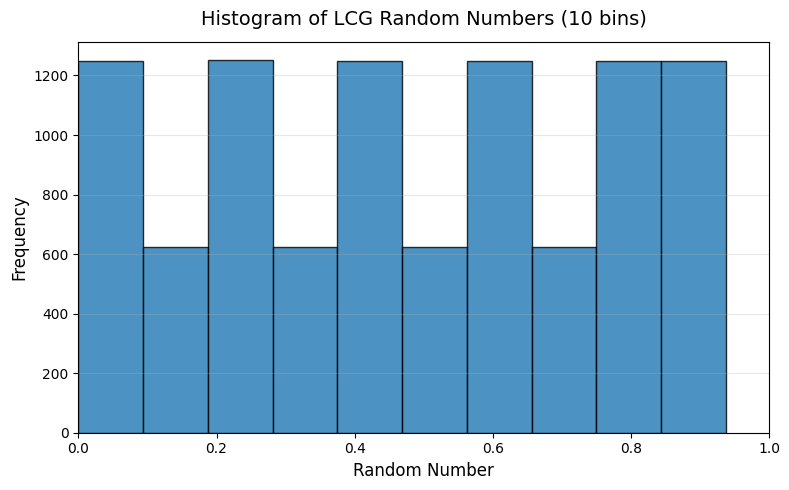

In [771]:
bins = 10

plt.figure(figsize=(8, 5))

plt.hist(
    RN,
    bins=bins,
    edgecolor="black",
    linewidth=1,
    alpha=0.8
)

plt.title(
    f"Histogram of LCG Random Numbers ({bins} bins)",
    fontsize=14,
    pad=12
)
plt.xlabel("Random Number", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.xlim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### (b)

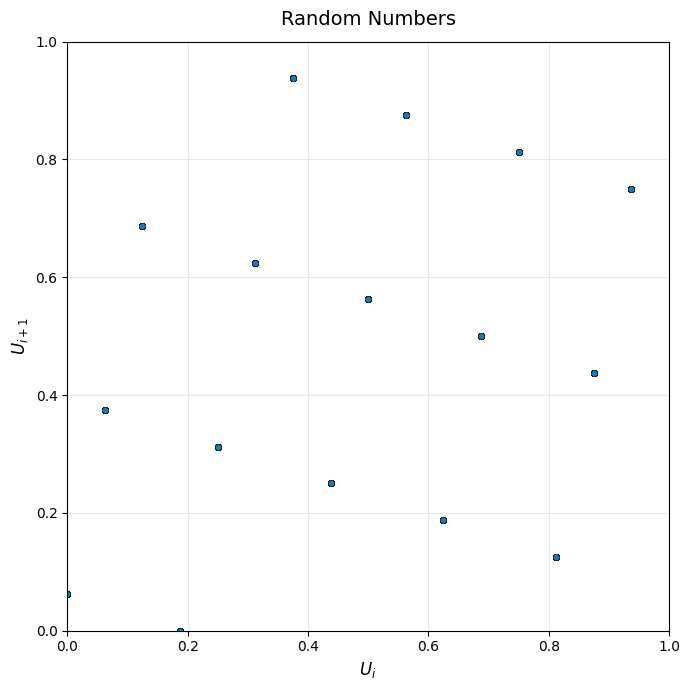

In [772]:
# Scatterplot 

plt.figure(figsize=(7, 7))

plt.scatter(
    RN[:-1],
    RN[1:],
    s=20,          # marker size
    alpha=0.6,     # transparency
    edgecolors='black',
    linewidths=0.3
)

plt.title("Random Numbers", fontsize=14, pad=12)
plt.xlabel(r"$U_i$", fontsize=12)
plt.ylabel(r"$U_{i+1}$", fontsize=12)

plt.grid(alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [773]:
# Define function to do a Chi-squared test 

def T_chi_square(n_observed, n_expected, m): 
    """
    Do a chi_square test
    Input: 
        n_observed: Array with the number of observed numbers at each bin 
        n_expected: The expected number of numbers at each bin given the expected distribution 
        m: The number of estimated parameters 
    
    Output: The p_value for hypothesis test 
    """
    
    n_observed = np.asarray(n_observed, dtype=float)
    n_expected = np.asarray(n_expected, dtype=float)
    n = len(n_observed)
    df = n-1-m
    T = np.sum(((n_observed-n_expected)**2)/n_expected)
    return chi2.sf(T,df)



In [774]:
# Chi-squared test with 10 bins

bins = 10
observed, _ = np.histogram(RN, bins=bins)
expected = np.ones(bins) * (10000 / bins)


print(f"p-value of chi_square test {T_chi_square(observed,expected, 0)}") #Small p-value, very unlikely that derivation so large if the data followed a uniform distribution 

p-value of chi_square test 4.0029422697053997e-196


In [775]:
def ecdf(x,obs): 
    """
    Compute the emperical cdf
    Input: 
        x: Float, value we want to evaluate the cdf. 
        obs: list of observations 
    Output: Emperical cdf evaluated at x
    """

    obs = np.array(obs)

    ecdf = np.sum(obs <= x)/len(obs)
    return ecdf

def uniform_cdf(x, a=0, b=1):
    """ 
    Compute theortical uniform cdf 

    Input: 
        x: Float, value we want to evaluate the cdf. 
    Output: Uniform cdf value evaluate at x. 
    """
    if x < a:
        return 0.0
    elif x > b:
        return 1.0
    else:
        return (x - a) / (b - a)

def Kolmogorov_Smirnov(obs): 
    """
    Compute D_n for the Kolmogorov Smirnov test 

    Input: 
        obs: list of observations 
    
        Output: D_n 
    """
    x = np.linspace(0,1,100)
    F_n = []
    F = []
    for val in x:
        F_n.append(ecdf(val, obs))
        F.append(uniform_cdf(val))
    D_n = np.max(abs(np.array(F_n)- np.array(F)))

    return D_n


In [776]:
# Compute D_n
D_n = Kolmogorov_Smirnov(RN)

# Adjusted test statistic 
n = len(RN)

print(f"Adjusted D_n: {(np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))*D_n}") # Not good result see slide 22

Adjusted D_n: 6.257255513199329


In [777]:
# Wald-Wolfowitz run test

def Wald_Wolfowitz(obs):
    """
    Do a Wald Wolfowitz run test 
    Input: 
        obs: list of observations 
    
        Output: p-value of the Wald Wolfowitz run test 
    """

    # Compute median 
    median = np.median(obs)
    above_below = []

    # Check if values in observations is above or below the median 
    for x in obs:
        if x > median:
            above_below.append(1)
        if x <= median: 
            above_below.append(0)
    
    # Compute the number of observation above and below the median 
    n1 = np.sum(above_below)
    n2 = len(above_below) - n1 
    runs = 1 
    # Count the number of runs 
    for i in range(1,len(above_below)):
        if above_below[i] != above_below[i-1]:
            runs += 1
    
    T = runs 
 
    # Compute the test statistik z for the p-value 
    mean = 2*n1*n2/(n1 + n2) +1 
    var = 2*(n1*n2*(2*n1*n2 -n1 - n2)/( (n1+n2)**2*(n1 + n2 -1)))
    z = (T - mean)/np.sqrt(var)
    
    p_values = 2*norm.sf(abs(z))
    return p_values
    


In [778]:
# Run test 1 (Above/below)
print(f"Above below run test p-value {Wald_Wolfowitz(RN)}")

Above below run test p-value 4.759054458520932e-138


In [779]:
def knuth(obs):
    """
    Do Knuth's run-length test 
    Input: 
        obs: list of observations 
    
        Output: p-value of the Knuth's run-length test 
    """
    obs = np.array(obs)
    n = len(obs)

    # Compute increasing runs
    lengths = []
    current_len = 1

    for i in range(1, n):
        if obs[i] > obs[i - 1]:
            current_len += 1
        else:
            lengths.append(current_len)
            current_len = 1

    
    # Find the R vector 
    R = np.zeros(6)
    for r in lengths:
        if r <= 5: 
            R[r-1] += 1 
        else: 
            R[5] += 1 
    
    # Define A and B
    A = np.array([
    [4529.4,  9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    B = np.array([
    [1/6],
    [5/24],
    [11/120],
    [19/720],
    [29/5040],
    [1/840]
    ])

    
    d = R - n*B.flatten()
    Z = (d.T @ A @ d) / (n - 6)
    


    
    df = 6
    p_value = chi2.sf(Z,df)
  
    return p_value
            
    

In [780]:
# Knuth run test (up/down)
print(f"Up/down run test p-value: {knuth(RN)}")

Up/down run test p-value: 1.4733787998841428e-238


In [781]:
def correlation_test(obs,h):
    """ 
    Do a correlation test 
    Input: 
        obs: list of observations 
        h: lag 
    
    Output: p-value for the correlation test 
    """
    obs = np.array(RN)
    n= len(obs)
    c = np.sum(obs[:-h] * obs[h:]) / (n - h)

    mean = 0.25
    var = 7/(144*n)
    z = (c - mean)/np.sqrt(var)
    
    p_values = 2*norm.sf(abs(z))
    return p_values

In [782]:
h = [1,3,5,6]
for element in h: 
    print(f"p-value correlation test: {correlation_test(RN,element)}, h = {element}")


p-value correlation test: 0.00039471242218985114, h = 1
p-value correlation test: 1.1720063046768725e-135, h = 3
p-value correlation test: 2.3477047724179072e-26, h = 5
p-value correlation test: 3.3930716474674713e-51, h = 6


#### (c)

In [810]:

# GOOD example 
x0 = 2 
M = 2**32 
a = 1203515245
c = 12345
iter = 10000 
RN = LCG(x0, a, c, M, iter)


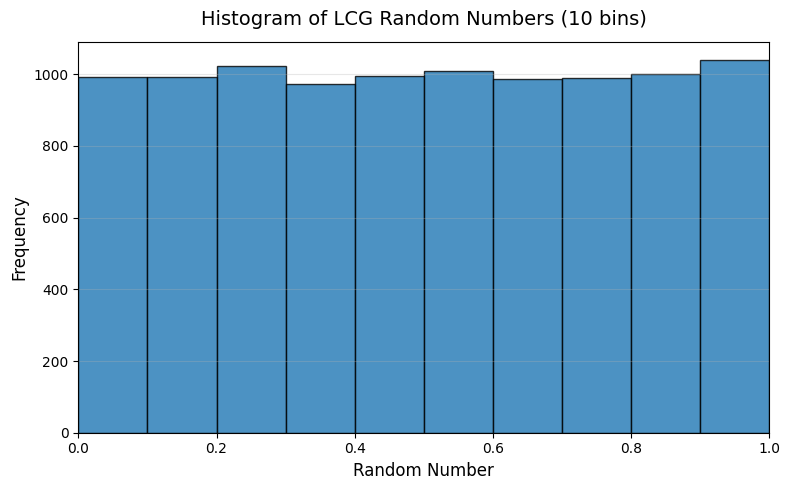

In [811]:
# Histogram 
bins = 10

plt.figure(figsize=(8, 5))

plt.hist(
    RN,
    bins=bins,
    edgecolor="black",
    linewidth=1,
    alpha=0.8
)

plt.title(
    f"Histogram of LCG Random Numbers ({bins} bins)",
    fontsize=14,
    pad=12
)
plt.xlabel("Random Number", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.xlim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

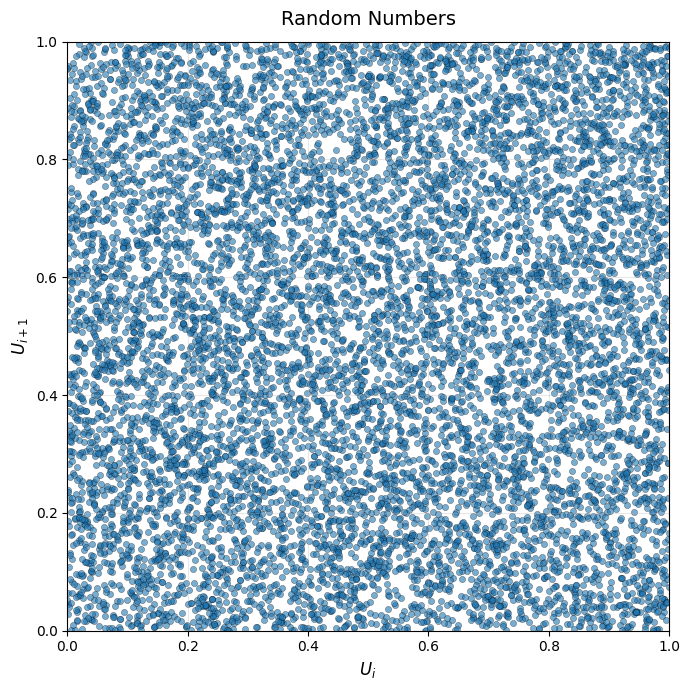

In [812]:
# Scatterplot 

plt.figure(figsize=(7, 7))

plt.scatter(
    RN[:-1],
    RN[1:],
    s=20,          # marker size
    alpha=0.6,     # transparency
    edgecolors='black',
    linewidths=0.3
)

plt.title("Random Numbers", fontsize=14, pad=12)
plt.xlabel(r"$U_i$", fontsize=12)
plt.ylabel(r"$U_{i+1}$", fontsize=12)

plt.grid(alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [813]:
# Chi-squared test with 10 bins

bins = 10
observed, _ = np.histogram(RN, bins=bins)
expected = np.ones(bins) * (10000 / bins)


print(f"p-value of chi_square test {T_chi_square(observed,expected, 0)}") 


p-value of chi_square test 0.9493265886655313


In [814]:
# Compute D_n
D_n = Kolmogorov_Smirnov(RN)

# Adjusted test statistic 
print(f"Adjusted D_n: {(np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))*D_n}") 

Adjusted D_n: 0.5197686837376965


In [815]:
# Run test 1 (Above/below)
print(f"Above below run test p-value {Wald_Wolfowitz(RN)}")

Above below run test p-value 0.02852430695565274


In [816]:
# Knuth run test (up/down)
print(f"Up/down run test p-value: {knuth(RN)}")

Up/down run test p-value: 0.16447844145177415


In [817]:
h = [1,3,5,6]
for element in h: 
    print(f"p-value correlation test: {correlation_test(RN,element)},h = {element}")

p-value correlation test: 0.15144114303806372,h = 1
p-value correlation test: 0.7155167285473527,h = 3
p-value correlation test: 0.3632782844797088,h = 5
p-value correlation test: 0.40690599290045637,h = 6


### Exercise 2 

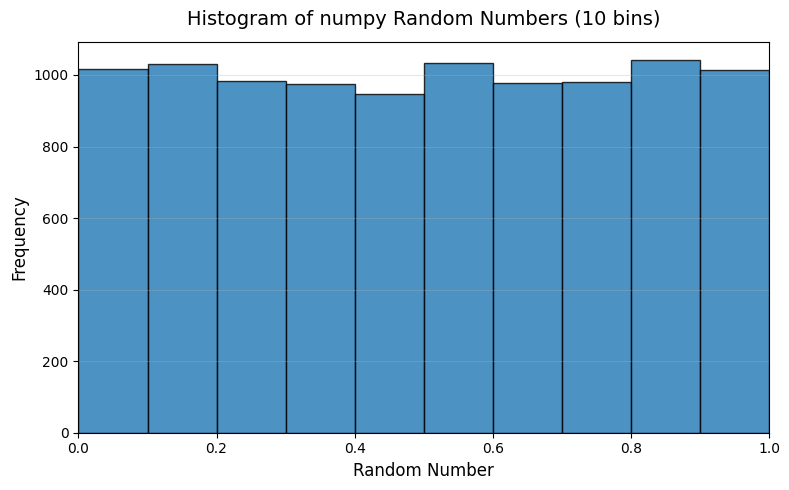

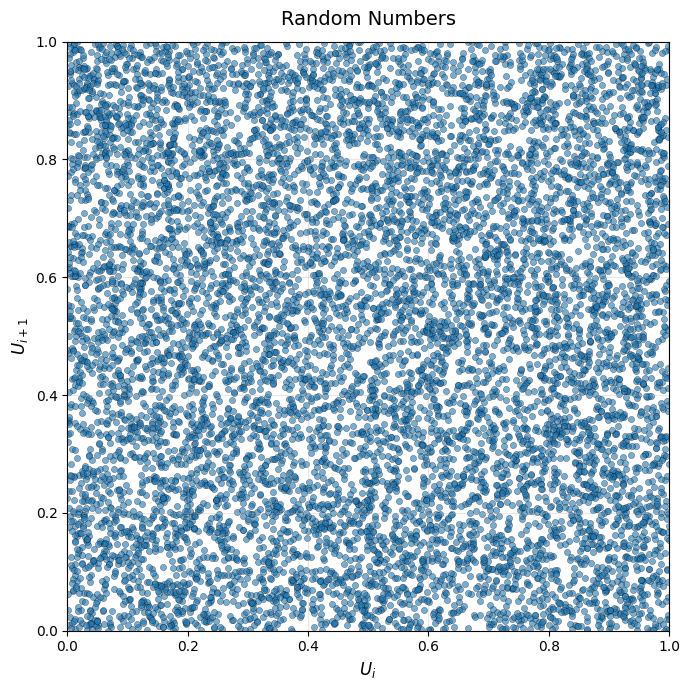

p-value of chi_square test 0.4433887882374703
Adjusted D_n: 0.8487456865550851
Above below run test p-value: 0.6454997087450891
Up/down run test p-value: 0.4203092142415113
p-value correlation test: 0.00852412349889195, h = 1
p-value correlation test: 0.0212339168393527, h = 3
p-value correlation test: 0.014796247909214744, h = 5
p-value correlation test: 0.060412609706459126, h = 6


In [791]:
RN_sys = np.random.rand(10000)

# Histogram 
bins = 10

plt.figure(figsize=(8, 5))

plt.hist(
    RN_sys,
    bins=bins,
    edgecolor="black",
    linewidth=1,
    alpha=0.8
)

plt.title(
    f"Histogram of numpy Random Numbers ({bins} bins)",
    fontsize=14,
    pad=12
)
plt.xlabel("Random Number", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.xlim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Scatterplot 

plt.figure(figsize=(7, 7))

plt.scatter(
    RN_sys[:-1],
    RN_sys[1:],
    s=20,          # marker size
    alpha=0.6,     # transparency
    edgecolors='black',
    linewidths=0.3
)

plt.title("Random Numbers", fontsize=14, pad=12)
plt.xlabel(r"$U_i$", fontsize=12)
plt.ylabel(r"$U_{i+1}$", fontsize=12)

plt.grid(alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# Chi-squared test with 10 bins

bins = 10
bins = 10
observed, _ = np.histogram(RN_sys, bins=bins)
expected = np.ones(bins) * (10000 / bins)


print(f"p-value of chi_square test {T_chi_square(observed,expected, 0)}") 

# Compute D_n
D_n = Kolmogorov_Smirnov(RN_sys)

# Adjusted test statistic 
print(f"Adjusted D_n: {(np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))*D_n}") 

# Run test 1 (Above/below)
print(f"Above below run test p-value: {Wald_Wolfowitz(RN_sys)}")

# Knuth run test (up/down)
print(f"Up/down run test p-value: {knuth(RN_sys)}")

h = [1,3,5,6]
for element in h: 
    print(f"p-value correlation test: {correlation_test(RN_sys,element)}, h = {element}")


### Exercise 3

The problem with this approach is that it is deterministic. Given the inital values we will obtain one sequence of numbers, that we can evalute the distribution on. Ideally we should use the LCG model to generate more sequences of number, so that we can check how good the method is. One could get "lucky" and have a good inital number, when in reality the generator could perform badly in most cases. Next step would be to generate many sequences and compare. In the following we only check if the sequence pass the chi_square test. We only change the starting point

In [809]:
seeds = np.arange(1, 501) 
M = 2**32 
a = 1203515245
c = 12345
iter = 10000 

Number_of_passed = 0 
p_values = []
for element in seeds: 
    RN = LCG(element, a, c, M, iter)
    bins = 10
    bins = 10
    observed, _ = np.histogram(RN, bins=bins)
    expected = np.ones(bins) * (iter / bins)
    p = T_chi_square(observed,expected, 0)
    
    if p >= 0.005: 
        p_values.append(p)
        Number_of_passed += 1


print(f"Number of passed sequences: {Number_of_passed} for a = {a}, M = {M}, c = {c}.")

Number of passed sequences: 498 for a = 1203515245, M = 4294967296, c = 12345.


In [ ]:
seeds = np.arange(1, 501) 
M = 16 
a = 5 
c = 1
iter = 10000 

Number_of_passed = 0 
p_values = []
for element in seeds: 
    RN = LCG(element, a, c, M, iter)
    bins = 10
    bins = 10
    observed, _ = np.histogram(RN, bins=bins)
    expected = np.ones(bins) * (iter / bins)
    p = T_chi_square(observed,expected, 0)
    
    if p >= 0.005: 
        p_values.append(p)
        Number_of_passed += 1

print(f"Number of passed sequences: {Number_of_passed} for a = {a}, M = {M}, c = {c}.")

Number of passed sequences: 0 for a = 5, M =16, c = 1


## Day 2 

### Part 1

In [ ]:
# Test example to make geometric sample 
p = 0.3 
n = 10000

np.random.seed(42)
U = np.random.rand(n)

geometric_sample = np.floor(np.log(U)/np.log(1-p)) + 1
geometric_sample


array([3., 1., 1., ..., 1., 3., 5.], shape=(10000,))

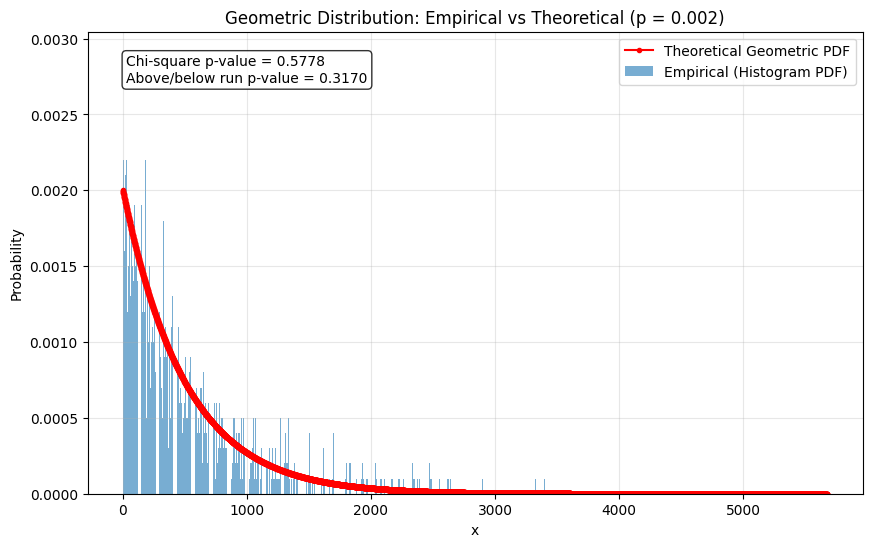

Chi-square p-value: 0.5777722599192963
Above/below run p-value: 0.3170497936724864


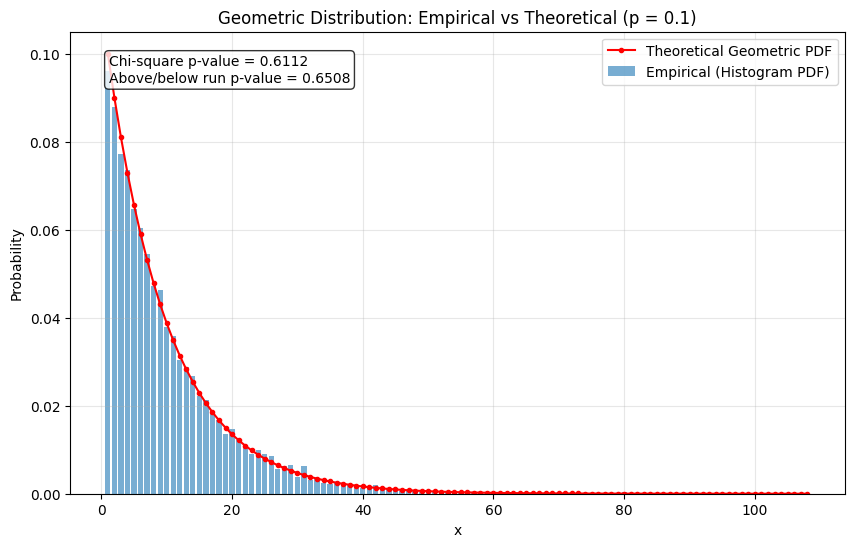

Chi-square p-value: 0.6111663260385857
Above/below run p-value: 0.6508375002402667


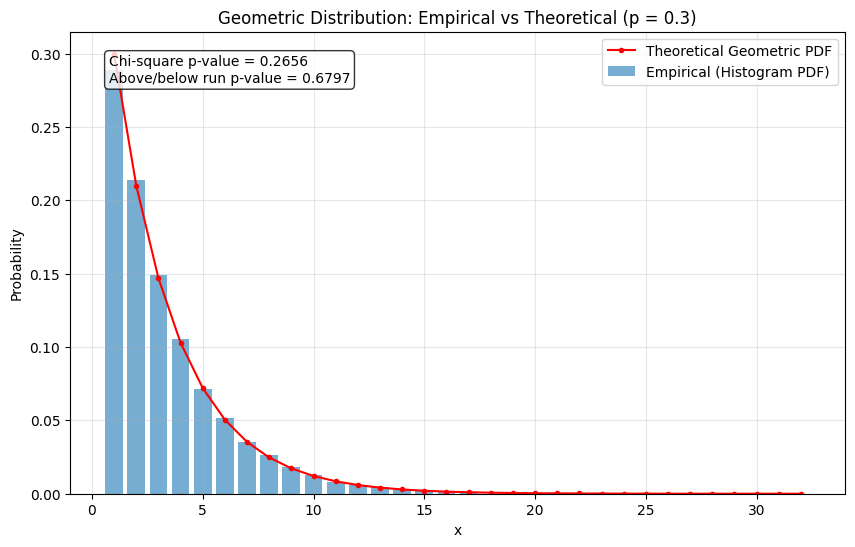

Chi-square p-value: 0.2655817547572496
Above/below run p-value: 0.679732994646891


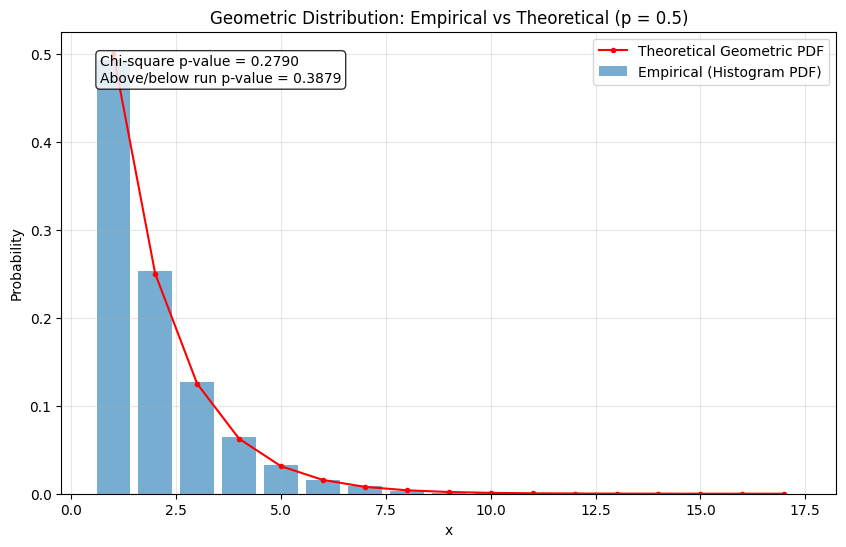

Chi-square p-value: 0.2790052223365163
Above/below run p-value: 0.38794690237893914


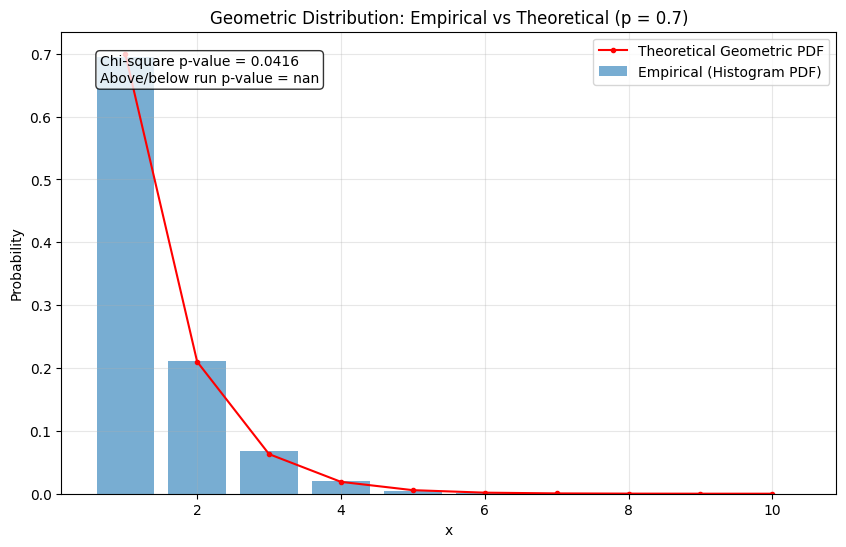

Chi-square p-value: 0.041554385418533846
Above/below run p-value: nan


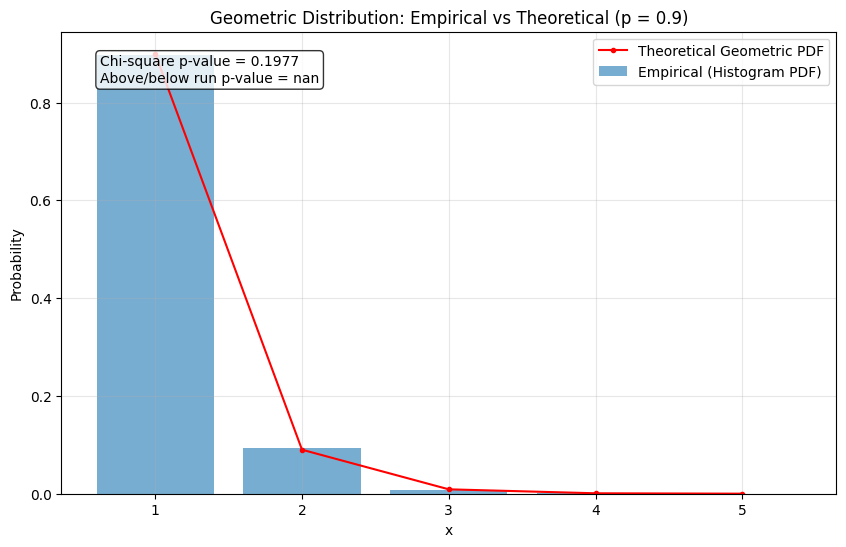

Chi-square p-value: 0.19765763629787836
Above/below run p-value: nan


In [ ]:
# Simulated geometric distributions for different values of p
p = [0.002,0.1,0.3,0.5,0.7,0.9]

for element in p: 
    # Simulate geometric sample 
    np.random.seed(42)
    n = 10000
    U = np.random.rand(n)
    geometric_sample = (np.floor(np.log(U)/np.log(1-element))).astype(int) + 1

    max_x = geometric_sample.max()
    x_vals = np.arange(1, max_x + 1)   

    obs_counts = np.bincount(geometric_sample, minlength=max_x+1)[1:]
    hist_pdf = obs_counts / n

    # Theorical pdf

    theoretical_pdf = element * (1 - element) ** (x_vals - 1)
    exp_counts = theoretical_pdf * n
  
    mask = exp_counts >= 5
    obs = obs_counts[mask]
    exp = exp_counts[mask]

    # Do chi-square test 
    exp = exp * (obs.sum() / exp.sum())
    chi_stat, p_value_chi = chisquare(f_obs=obs, f_exp=exp)
    
    # Do above/below run test 
    z_stat, p_value_run = runstest_1samp(geometric_sample, cutoff="median")

    # Plot theorical distribution vs. simulated distribution 
    plt.figure(figsize=(10, 6))
    plt.bar(x_vals, hist_pdf, alpha=0.6, label="Empirical (Histogram PDF)")
    plt.plot(x_vals, theoretical_pdf, 'r-', marker='o', markersize=3,
         label="Theoretical Geometric PDF")

    plt.title(f"Geometric Distribution: Empirical vs Theoretical (p = {element})")
    plt.xlabel("x")
    plt.ylabel("Probability")

    text = (
    f"Chi-square p-value = {p_value_chi:.4f}\n"
    f"Above/below run p-value = {p_value_run:.4f}"
     )
    plt.text(
    0.05, 0.95,
    text,
    transform=plt.gca().transAxes,
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
     )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()
    print("Chi-square p-value:", p_value_chi)
    print("Above/below run p-value:", p_value_run)
    
    

### Part 2

#### (1)

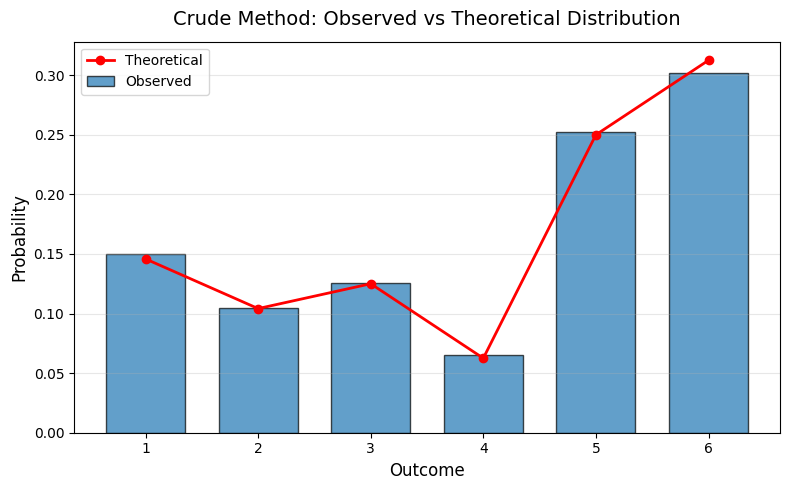

array([3, 6, 6, ..., 6, 4, 2], shape=(10000,))

In [ ]:
np.random.seed(42)

def crude(x, p, n):
    """
    Generate oberservations from discrete distribution using the crude method 

    Input: 
        x: np.array of possible outcomes 
        p: np.array of probability of each outcome 
        n: number of observations 
    
    Output: Simulated samples using the crude method
    """
    # Generete samples using crude method
    U = np.random.rand(n)
    intervals = np.cumsum(p)
    index = np.searchsorted(intervals, U, side='left')
    X = x[index]

    # Observed relative frequencies
    observed = np.bincount(X)[1:] / n

    plt.figure(figsize=(8, 5))

    # Observed
    plt.bar(
        x,
        observed,
        width=0.7,
        alpha=0.7,
        edgecolor="black",
        label="Observed"
    )

    # Theoretical
    plt.plot(
        x,
        p,
        marker="o",
        linewidth=2,
        label="Theoretical",
        color = "red"
    )

    # Plot distribution
    plt.title("Crude Method: Observed vs Theoretical Distribution",
              fontsize=14, pad=12)
    plt.xlabel("Outcome", fontsize=12)
    plt.ylabel("Probability", fontsize=12)

    plt.xticks(x)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return X


x = np.array([1,2,3,4,5,6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

n = 10000
samples = crude(x, p, n)
samples

#### (2)

0.3125


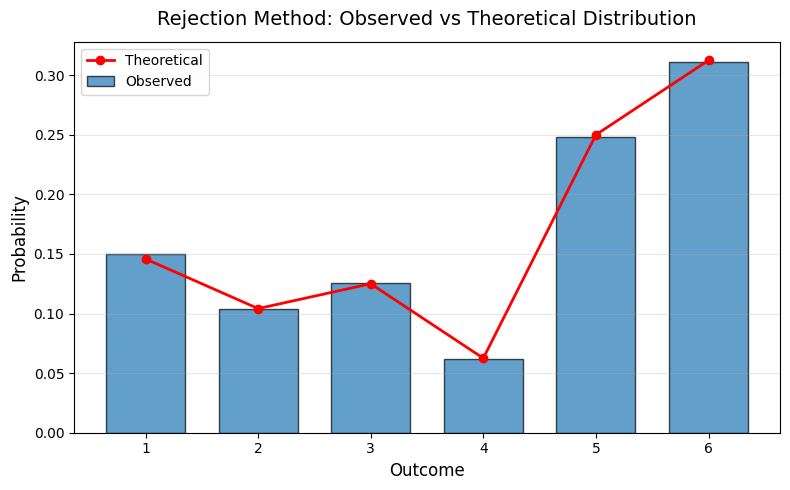

array([[6, 6, 6, ..., 5, 3, 6]], shape=(1, 10000))

In [830]:
# Rejection method 

def simple_rejection_method(x,p,n,c): 
    """
    Generate oberservations from discrete distribution using the crude method 

    Input: 
        x: np.array of possible outcomes 
        p: np.array of probability of each outcome 
        n: number of observations 
        c: constant bigger that max(p)
    
    Output: Simulated samples using the rejection method
    """
    
    # Generete samples using the rejection method
    k = np.max(x)
    X = []
    while len(X) < n:
        U1 = np.random.rand()

        I = (np.floor(k*U1) + 1).astype(int)
        pI = p[I-1] 
        if np.random.rand() <= pI/c: 
            X.append(I)

    # Observed relative frequencies
    observed = np.bincount(X)[1:] / n

    plt.figure(figsize=(8, 5))

    # Observed
    plt.bar(
        x,
        observed,
        width=0.7,
        alpha=0.7,
        edgecolor="black",
        label="Observed"
    )

    # Theoretical
    plt.plot(
        x,
        p,
        marker="o",
        linewidth=2,
        label="Theoretical",
        color = "red"
    )

    # Plot distribution
    plt.title("Rejection Method: Observed vs Theoretical Distribution",
              fontsize=14, pad=12)
    plt.xlabel("Outcome", fontsize=12)
    plt.ylabel("Probability", fontsize=12)

    plt.xticks(x)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()
        
    return np.array([X])

x = np.array([1,2,3,4,5,6])
p = [7/48,5/48, 1/8, 1/16,1/4,5/16]
print(np.max(p))
c = 0.32
n = 10000
k = np.max(x)

simple_rejection_method(x,p,n,c)



#### (3)

In [831]:
# Alias Method 

def gen_F_L(p, eps): 
    k = len(p)
    L = np.arange(1,k+1,1)
    F = k*np.array(p)
    G = [idx for idx in range(k) if F[idx] >= 1]
    S = [idx for idx in range(k) if F[idx] < 1]
 
    while len(S) > 0: 
        i = G[0]
        j = S[0]
        L[j] = i 
        F[i] = F[i] - (1 - F[j])
        if F[i] < 1 - eps:
            G.pop(0)
            S.append(i) 
        S.pop(0)
    
    return F, L


def alias_method(x,p,F, L):
    k = np.max(x)
    X = []
    while len(X) < 10000:
        U1 = np.random.rand()

        I = (np.floor(k*U1) + 1).astype(int)
        if np.random.rand() <= F[I - 1]: 
            X.append(I)
        else: 
            X.append(L[I])

    # Observed relative frequencies
    observed = np.bincount(X)[1:] / n

    plt.figure(figsize=(8, 5))

    # Observed
    plt.bar(
        x,
        observed,
        width=0.7,
        alpha=0.7,
        edgecolor="black",
        label="Observed"
    )

    # Theoretical
    plt.plot(
        x,
        p,
        marker="o",
        linewidth=2,
        label="Theoretical",
        color = "red"
    )

    # Plot distribution
    plt.title("Rejection Method: Observed vs Theoretical Distribution",
              fontsize=14, pad=12)
    plt.xlabel("Outcome", fontsize=12)
    plt.ylabel("Probability", fontsize=12)

    plt.xticks(x)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return np.array([X])
    

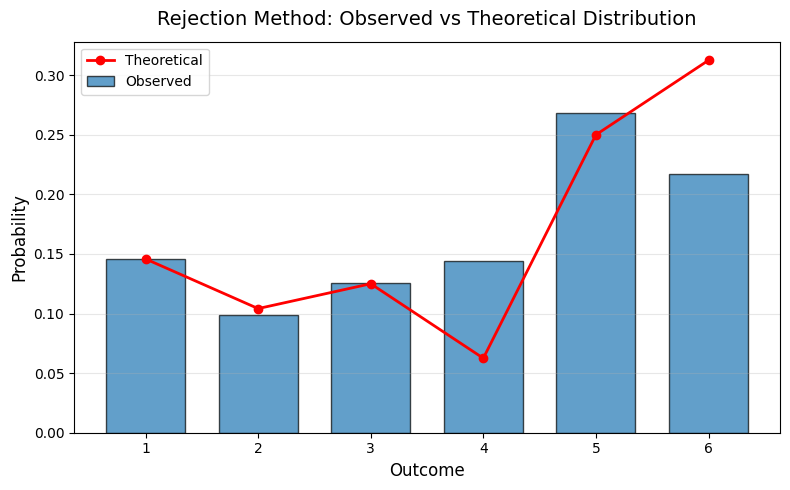

array([[5, 6, 3, ..., 4, 1, 3]], shape=(1, 10000))

In [832]:
eps = 0.001
x = np.array([1,2,3,4,5,6])
p = [7/48,5/48, 1/8, 1/16,1/4,5/16]

F, L = gen_F_L(p, eps)


alias_method(x,p,F,L)